In [5]:
# Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('../results/cluster_plots', exist_ok=True)
os.makedirs('../results/pca_outputs',   exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load final data
df          = pd.read_csv('../data/processed/final_clusters.csv')
df_pca_2d   = pd.read_csv('../data/processed/features_pca_2d.csv')
df_pca_3d   = pd.read_csv('../data/processed/features_pca_3d.csv')
df_scaled   = pd.read_csv('../data/processed/features_scaled.csv')

X_pca_2d  = df_pca_2d.drop(columns=['Customer ID']).values
X_pca_3d  = df_pca_3d.drop(columns=['Customer ID']).values
X_scaled  = df_scaled.drop(columns=['Customer ID']).values
labels    = df['Final_Cluster'].values

N_CLUSTERS = df['Final_Cluster'].nunique()
print(f"✅ Loaded final clusters: {df.shape}")
print(f"   Number of clusters : {N_CLUSTERS}")
print(f"   Total customers    : {len(df):,}")

✅ Loaded final clusters: (5878, 14)
   Number of clusters : 2
   Total customers    : 5,878


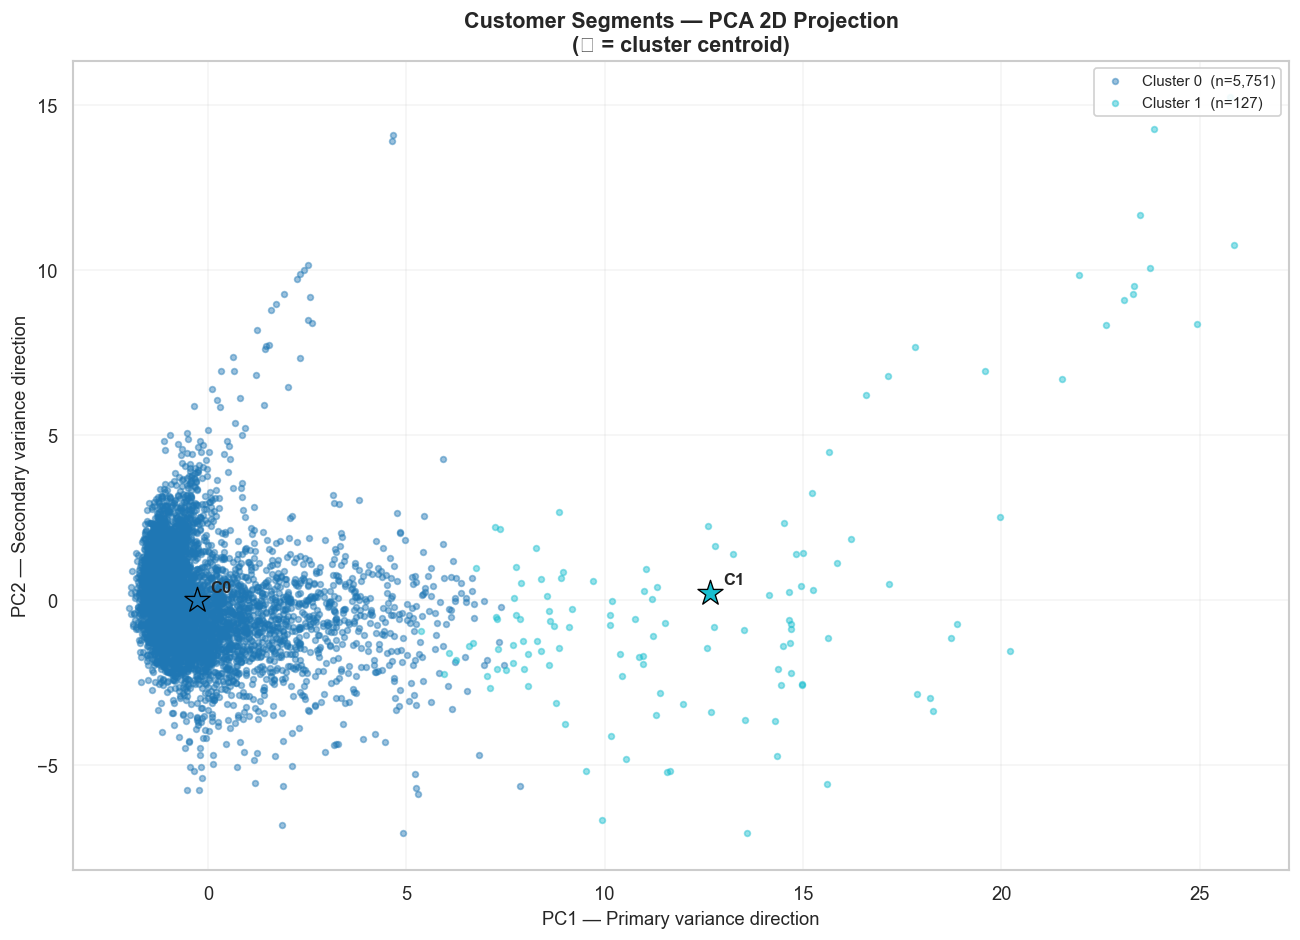

✅ Saved: final_clusters_pca2d.png


In [6]:
# PCA 2D — publication quality cluster plot

COLORS = plt.cm.tab10(np.linspace(0, 1, N_CLUSTERS))

fig, ax = plt.subplots(figsize=(11, 8))

for cid in sorted(df['Final_Cluster'].unique()):
    mask = labels == cid
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               color=COLORS[cid], alpha=0.45, s=12,
               label=f'Cluster {cid}  (n={mask.sum():,})')

# Plot centroids
for cid in sorted(df['Final_Cluster'].unique()):
    mask = labels == cid
    cx, cy = X_pca_2d[mask, 0].mean(), X_pca_2d[mask, 1].mean()
    ax.scatter(cx, cy, color=COLORS[cid], s=250,
               marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(f'C{cid}', (cx, cy),
                textcoords='offset points', xytext=(8, 5),
                fontsize=10, fontweight='bold')

ax.set_xlabel('PC1 — Primary variance direction', fontsize=11)
ax.set_ylabel('PC2 — Secondary variance direction', fontsize=11)
ax.set_title('Customer Segments — PCA 2D Projection\n(★ = cluster centroid)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../results/pca_outputs/final_clusters_pca2d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: final_clusters_pca2d.png")

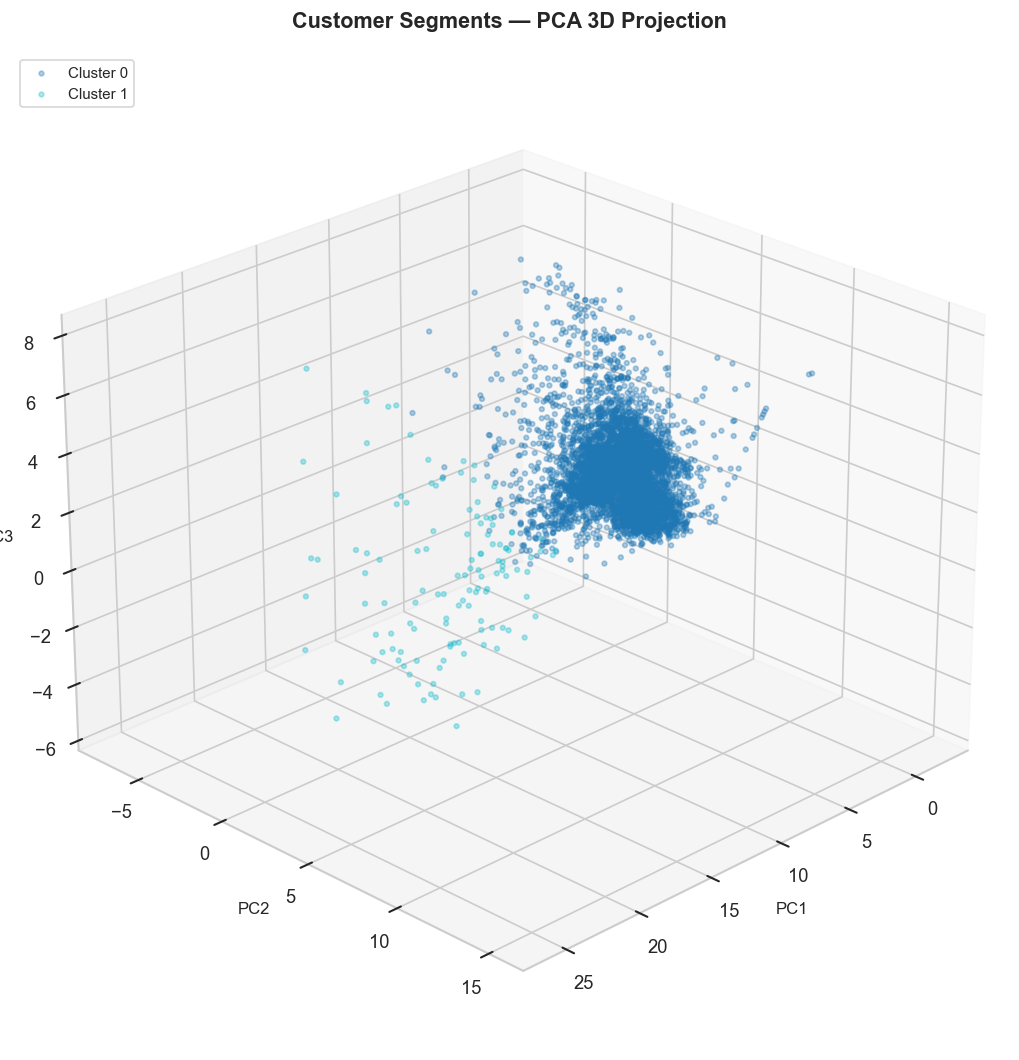

✅ Saved: final_clusters_pca3d.png


In [7]:
# PCA 3D cluster visualization

from mpl_toolkits.mplot3d import Axes3D   # noqa

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

for cid in sorted(df['Final_Cluster'].unique()):
    mask = labels == cid
    ax.scatter(X_pca_3d[mask, 0],
               X_pca_3d[mask, 1],
               X_pca_3d[mask, 2],
               color=COLORS[cid], alpha=0.35, s=8,
               label=f'Cluster {cid}')

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('PC3', fontsize=10)
ax.set_title('Customer Segments — PCA 3D Projection',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=9)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.savefig('../results/pca_outputs/final_clusters_pca3d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: final_clusters_pca3d.png")

Running t-SNE on 3000 customers ... (takes ~1–2 minutes)


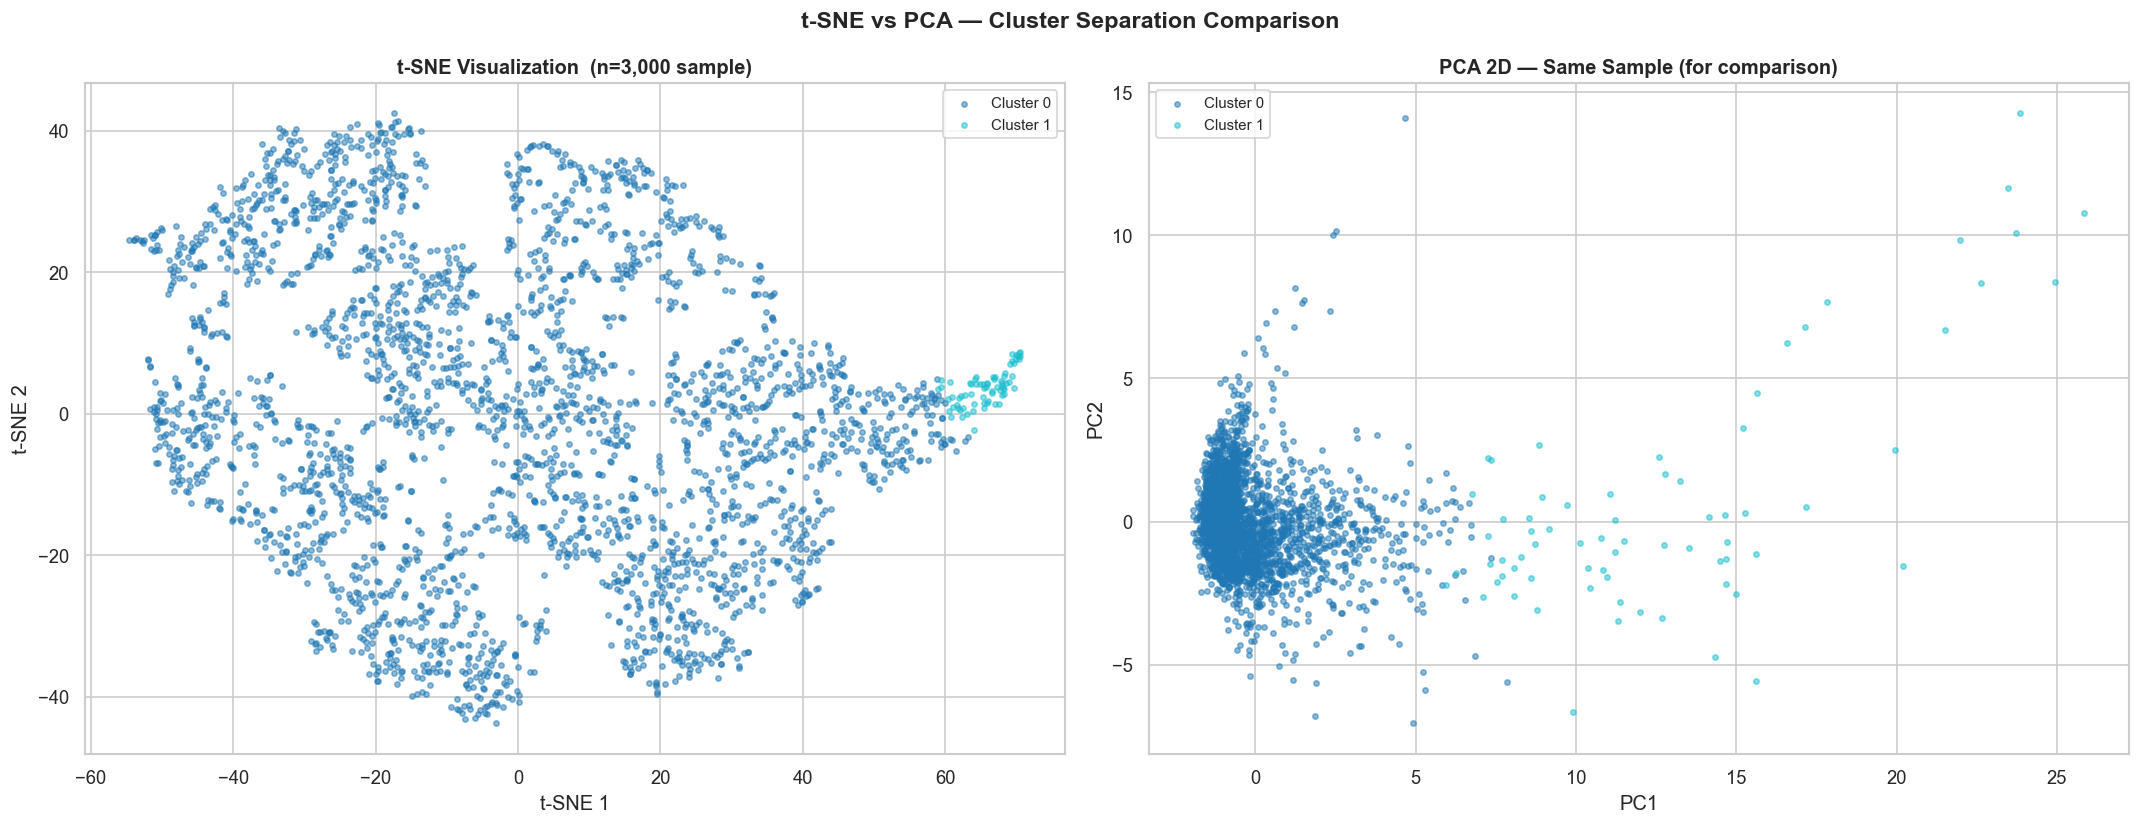

✅ Saved: tsne_vs_pca.png  (bonus t-SNE complete)


In [8]:
# t-SNE — non-linear 2D visualization (bonus points)

SAMPLE_SIZE = min(3000, len(df))
sample_idx  = np.random.RandomState(42).choice(len(df), SAMPLE_SIZE, replace=False)

X_sample      = X_scaled[sample_idx]
labels_sample = labels[sample_idx]

print(f"Running t-SNE on {SAMPLE_SIZE} customers ... (takes ~1–2 minutes)")

tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=42, max_iter=1000)   # ← n_iter → max_iter
X_tsne = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE plot
for cid in sorted(set(labels_sample)):
    mask = labels_sample == cid
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    color=COLORS[cid], alpha=0.5, s=10,
                    label=f'Cluster {cid}')
axes[0].set_title(f't-SNE Visualization  (n={SAMPLE_SIZE:,} sample)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(fontsize=9)

# PCA 2D same sample for comparison
for cid in sorted(set(labels_sample)):
    mask = labels_sample == cid
    axes[1].scatter(X_pca_2d[sample_idx][mask, 0],
                    X_pca_2d[sample_idx][mask, 1],
                    color=COLORS[cid], alpha=0.5, s=10,
                    label=f'Cluster {cid}')
axes[1].set_title('PCA 2D — Same Sample (for comparison)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)

plt.suptitle('t-SNE vs PCA — Cluster Separation Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/pca_outputs/tsne_vs_pca.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: tsne_vs_pca.png  (bonus t-SNE complete)")

In [9]:
# Build detailed cluster profiles for business interpretation

profile_features = [
    'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'TotalItems', 'UniqueProducts', 'CustomerAge',
    'AvgDaysBetweenOrders', 'SpendPerItem', 'cancellation_rate'
]

profiles = df.groupby('Final_Cluster')[profile_features].agg(['mean', 'median'])
profiles.columns = ['_'.join(c) for c in profiles.columns]

# Customer count per cluster
sizes = df['Final_Cluster'].value_counts().sort_index()
profiles['customer_count'] = sizes
profiles['customer_pct']   = (sizes / len(df) * 100).round(1)

# Revenue contribution
total_revenue = df['Monetary'].sum()
revenue_by_cluster = df.groupby('Final_Cluster')['Monetary'].sum()
profiles['revenue_contribution_pct'] = (revenue_by_cluster / total_revenue * 100).round(1)

print("CLUSTER PROFILES — RAW STATISTICS")
print("=" * 70)
display_cols = ['customer_count', 'customer_pct', 'revenue_contribution_pct',
                'Recency_mean', 'Frequency_mean', 'Monetary_mean',
                'AvgOrderValue_mean', 'UniqueProducts_mean',
                'cancellation_rate_mean']
print(profiles[display_cols].round(2).to_string())

CLUSTER PROFILES — RAW STATISTICS
               customer_count  customer_pct  revenue_contribution_pct  Recency_mean  Frequency_mean  Monetary_mean  AvgOrderValue_mean  UniqueProducts_mean  cancellation_rate_mean
Final_Cluster                                                                                                                                                                      
0                        5751          97.8                      97.9        199.02            5.84        2353.72               27.09                83.35                    0.02
1                         127           2.2                       2.1        302.50            3.15        2316.41              100.66                20.54                    0.40


In [10]:
# Assign business segment names based on cluster profiles

means = df.groupby('Final_Cluster')[
    ['Recency','Frequency','Monetary']
].mean()


means['R_rank'] = means['Recency'].rank(ascending=True)
means['F_rank'] = means['Frequency'].rank(ascending=False)
means['M_rank'] = means['Monetary'].rank(ascending=False)
means['RFM_rank'] = means['R_rank'] + means['F_rank'] + means['M_rank']

# Sort by overall RFM rank
means = means.sort_values('RFM_rank')


SEGMENT_LABELS = {
    0: "Champions",
    1: "Loyal Customers",
    2: "Potential Loyalists",
    3: "At-Risk Customers",
    4: "Lost / Churned",
}

# Auto-assign by RFM rank position
cluster_name_map = {}
label_list = list(SEGMENT_LABELS.values())
for i, cid in enumerate(means.index):
    cluster_name_map[cid] = label_list[i] if i < len(label_list) \
                            else f"Segment {i}"

df['Segment_Name'] = df['Final_Cluster'].map(cluster_name_map)

print("Segment Name Assignments:")
print("-" * 45)
for cid, name in cluster_name_map.items():
    n = (df['Final_Cluster'] == cid).sum()
    rev = df[df['Final_Cluster'] == cid]['Monetary'].sum()
    print(f"  Cluster {cid} → {name:<25} "
          f"n={n:,}  revenue=£{rev:,.0f}")

Segment Name Assignments:
---------------------------------------------
  Cluster 0 → Champions                 n=5,751  revenue=£13,536,234
  Cluster 1 → Loyal Customers           n=127  revenue=£294,184


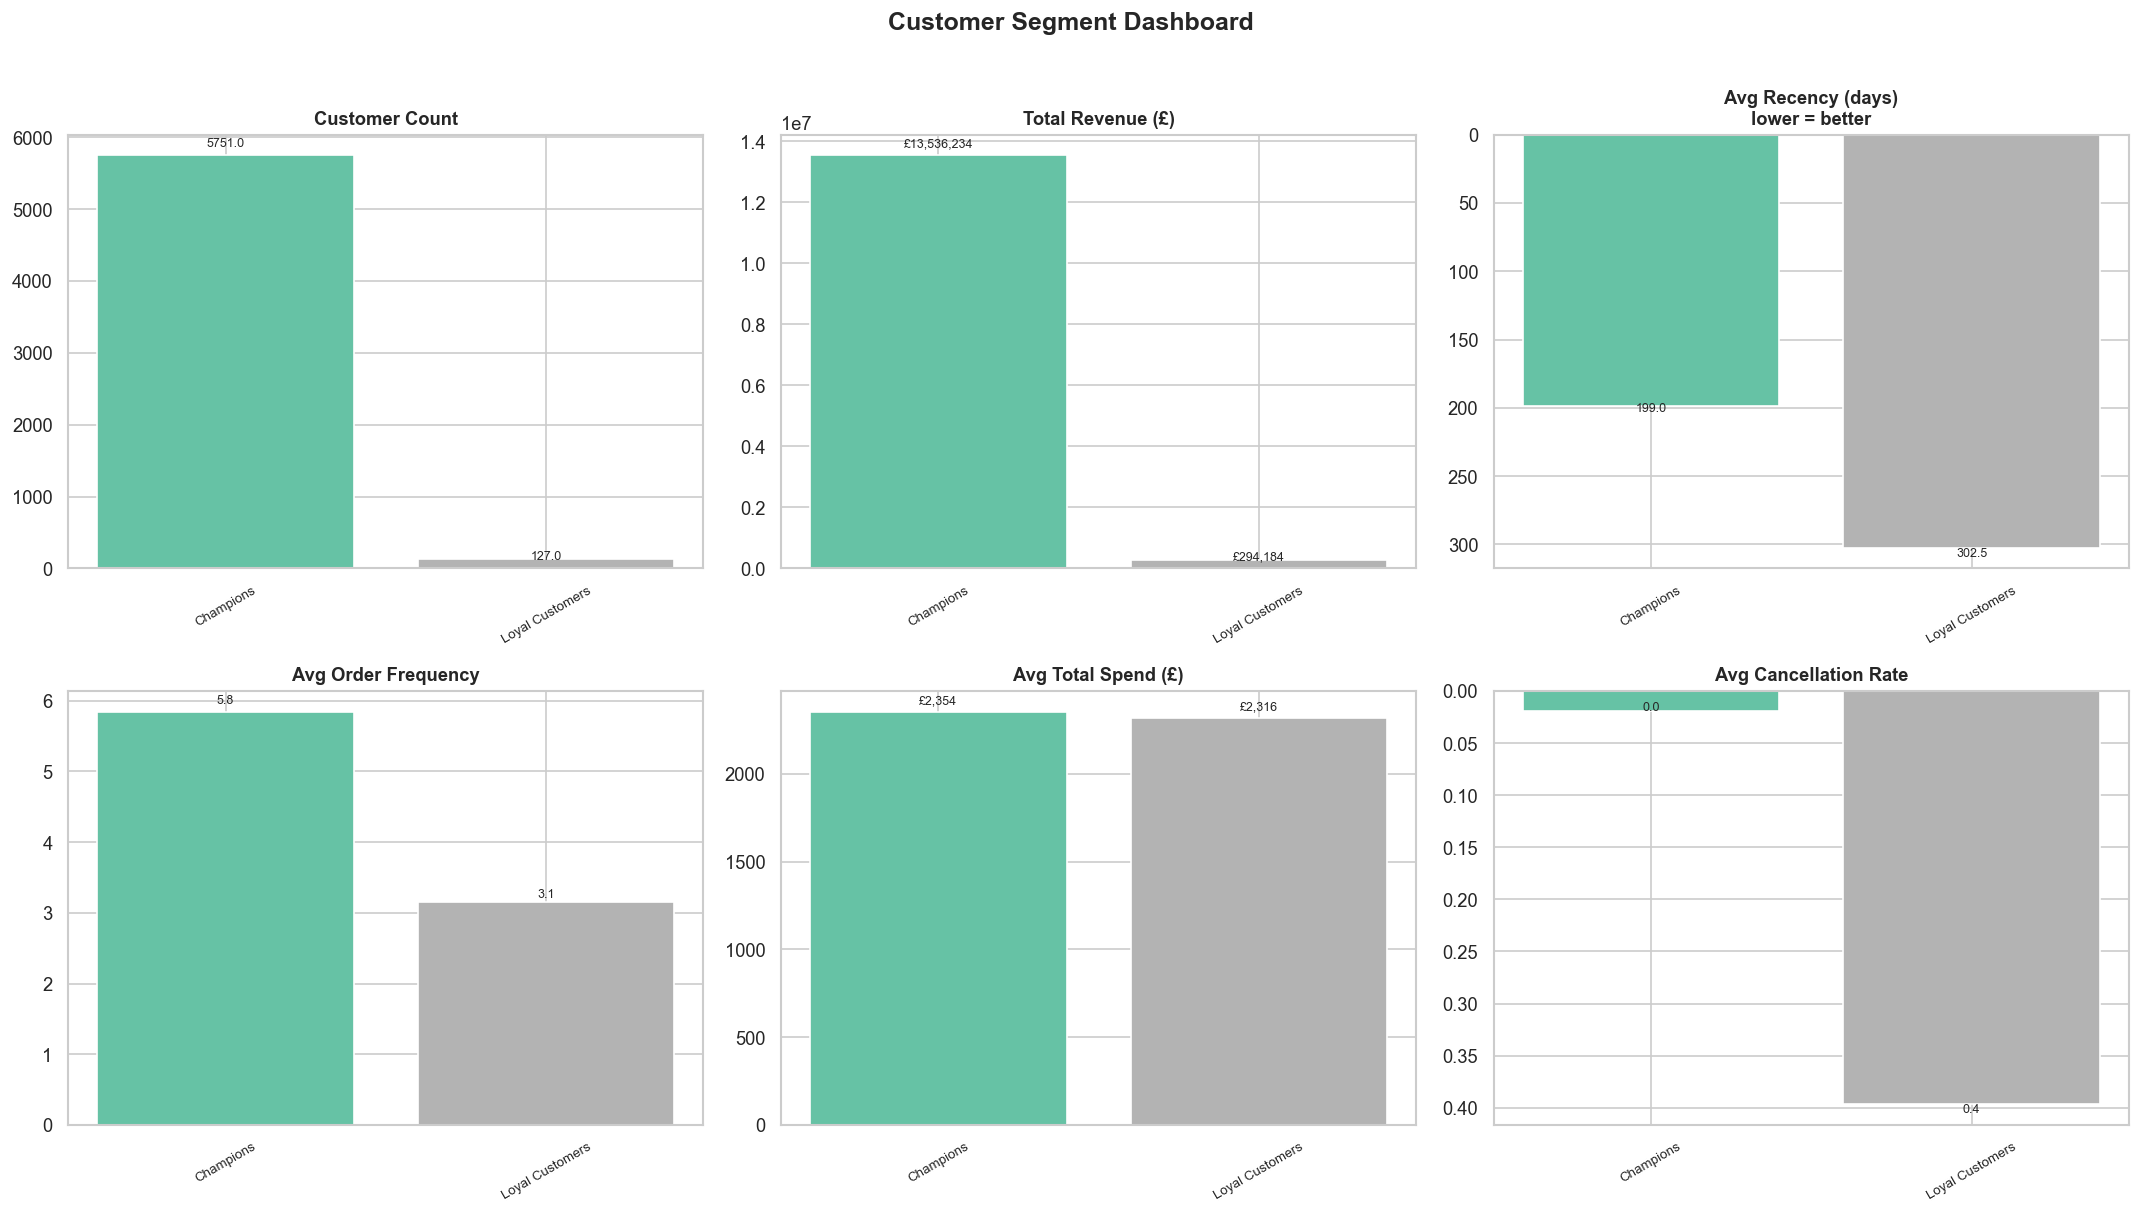

✅ Saved: segment_dashboard.png


In [11]:
# Visual segment summary dashboard

segment_stats = df.groupby('Segment_Name').agg(
    Customers     = ('Customer ID',   'count'),
    Avg_Recency   = ('Recency',       'mean'),
    Avg_Frequency = ('Frequency',     'mean'),
    Avg_Monetary  = ('Monetary',      'mean'),
    Total_Revenue = ('Monetary',      'sum'),
    Avg_CancelRate = ('cancellation_rate', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
seg_colors = plt.cm.Set2(np.linspace(0, 1, len(segment_stats)))

metrics_plot = [
    ('Customers',      'Customer Count',           False),
    ('Total_Revenue',  'Total Revenue (£)',        False),
    ('Avg_Recency',    'Avg Recency (days)\nlower = better', True),
    ('Avg_Frequency',  'Avg Order Frequency',      False),
    ('Avg_Monetary',   'Avg Total Spend (£)',       False),
    ('Avg_CancelRate', 'Avg Cancellation Rate',    True),
]

for ax, (col, title, invert) in zip(axes, metrics_plot):
    bars = ax.bar(segment_stats['Segment_Name'],
                  segment_stats[col],
                  color=seg_colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for bar, val in zip(bars, segment_stats[col]):
        label = f'£{val:,.0f}' if 'Revenue' in title or 'Spend' in title \
                else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                label, ha='center', fontsize=7.5)
    if invert:
        ax.invert_yaxis()

plt.suptitle('Customer Segment Dashboard', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/cluster_plots/segment_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: segment_dashboard.png")

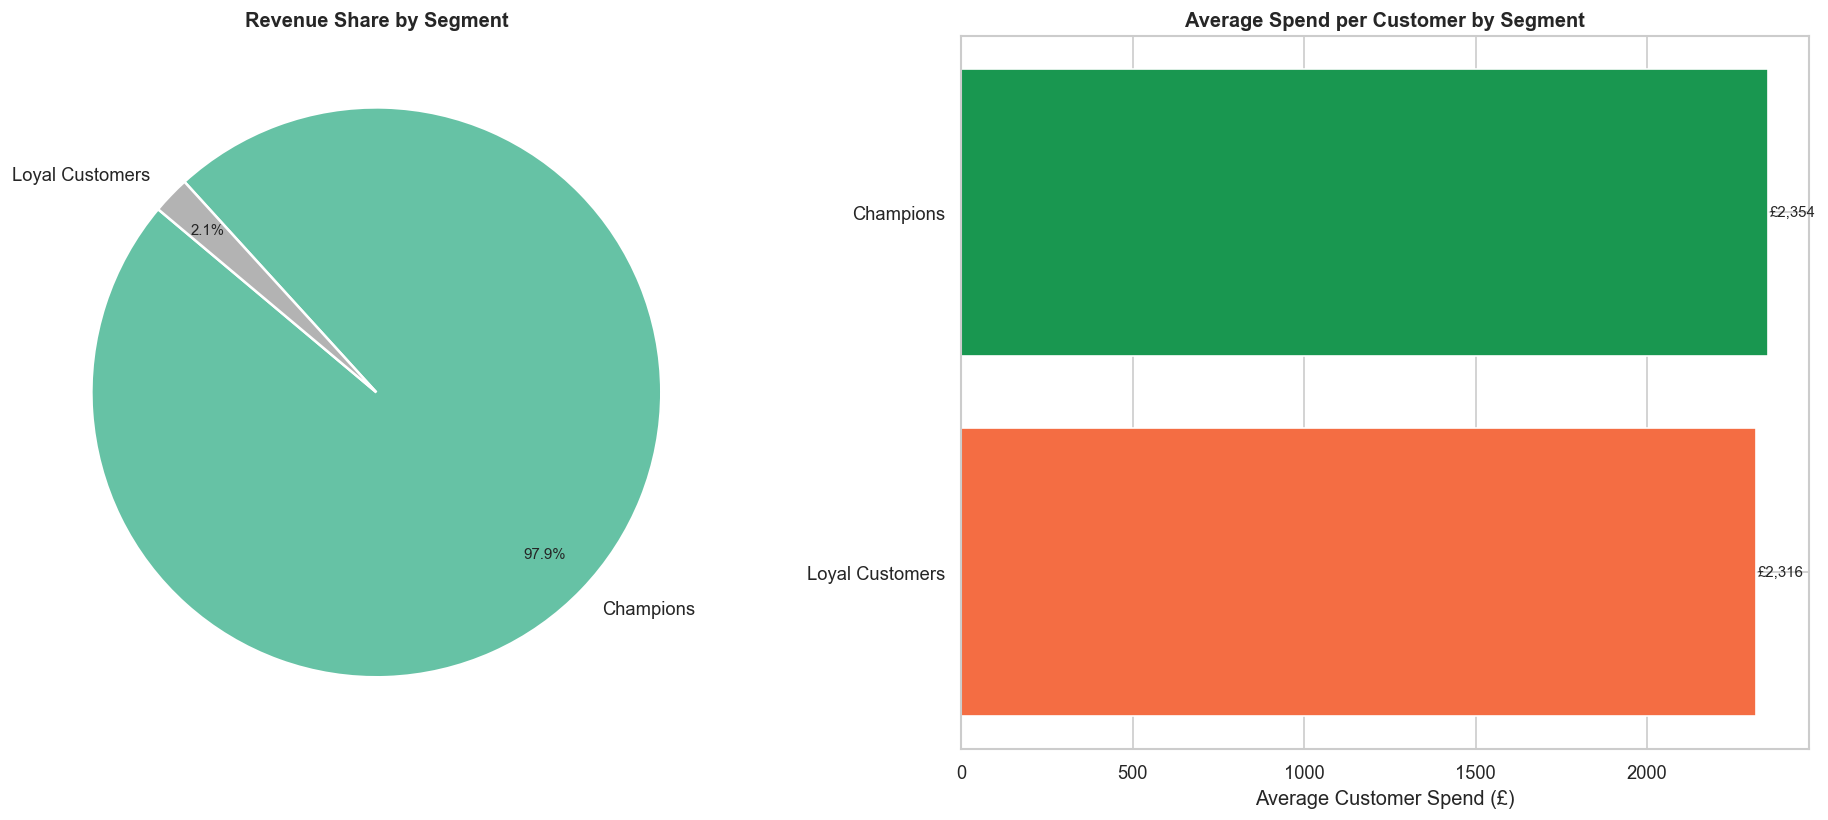

✅ Saved: revenue_by_segment.png


In [12]:
# Revenue contribution by segment

rev_by_seg = df.groupby('Segment_Name')['Monetary'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    rev_by_seg.values,
    labels=rev_by_seg.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set2(np.linspace(0, 1, len(rev_by_seg))),
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title('Revenue Share by Segment', fontweight='bold', fontsize=12)

# Horizontal bar — avg spend per customer
avg_spend = df.groupby('Segment_Name')['Monetary'].mean().sort_values()
colors_h  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(avg_spend)))
bars = axes[1].barh(avg_spend.index, avg_spend.values,
                    color=colors_h, edgecolor='white')
axes[1].set_xlabel('Average Customer Spend (£)')
axes[1].set_title('Average Spend per Customer by Segment',
                  fontweight='bold', fontsize=12)
for bar, val in zip(bars, avg_spend.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/cluster_plots/revenue_by_segment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: revenue_by_segment.png")

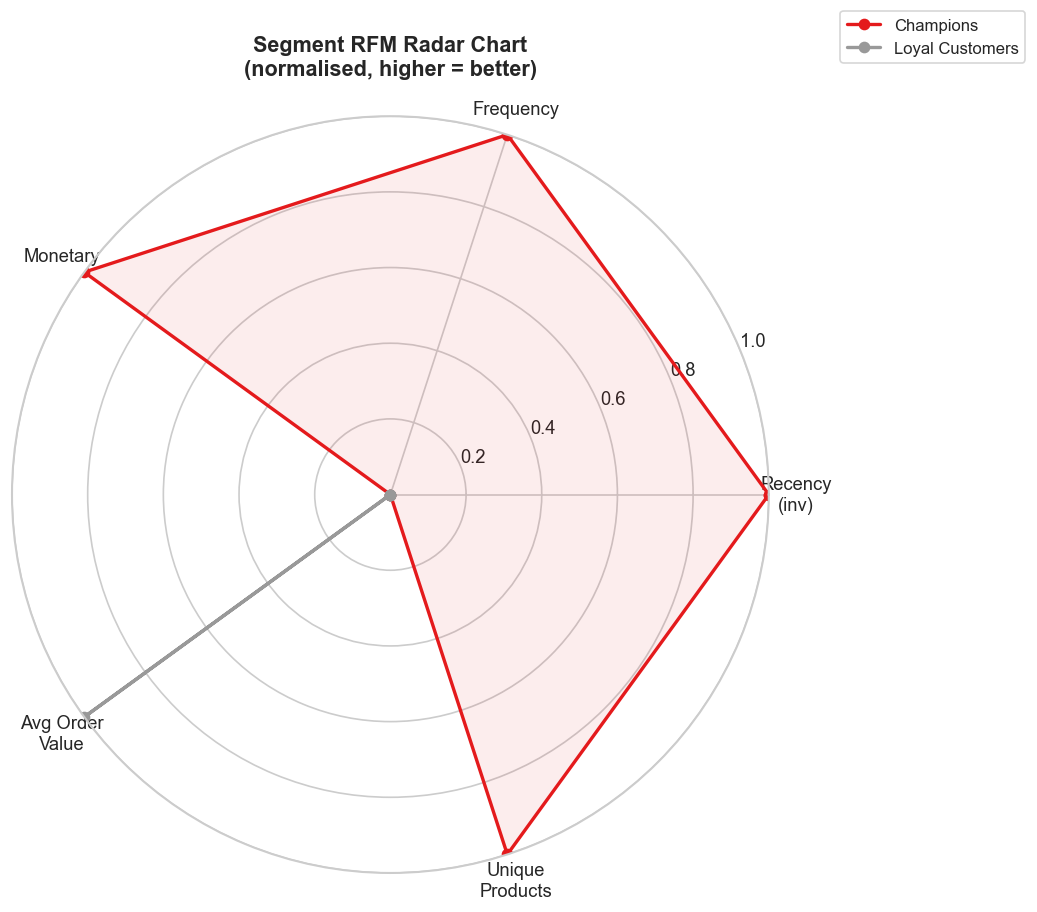

✅ Saved: rfm_radar_segments.png


In [13]:
# RFM spider/radar chart per segment

from math import pi

# Normalise RFM for radar (0–1 scale)
rfm_radar = df.groupby('Segment_Name')[
    ['Recency','Frequency','Monetary','AvgOrderValue','UniqueProducts']
].mean()

# Invert Recency so higher = better on radar
rfm_radar['Recency'] = rfm_radar['Recency'].max() - rfm_radar['Recency']

# Normalise 0-1
for col in rfm_radar.columns:
    col_min = rfm_radar[col].min()
    col_max = rfm_radar[col].max()
    rfm_radar[col] = (rfm_radar[col] - col_min) / (col_max - col_min + 1e-9)

categories = list(rfm_radar.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
spider_colors = plt.cm.Set1(np.linspace(0, 1, len(rfm_radar)))

for i, (seg, row) in enumerate(rfm_radar.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=spider_colors[i], label=seg)
    ax.fill(angles, values, alpha=0.08, color=spider_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    ['Recency\n(inv)', 'Frequency', 'Monetary',
     'Avg Order\nValue', 'Unique\nProducts'],
    fontsize=11
)
ax.set_ylim(0, 1)
ax.set_title('Segment RFM Radar Chart\n(normalised, higher = better)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('../results/cluster_plots/rfm_radar_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rfm_radar_segments.png")

In [14]:
# Full business insights — printed report

print("""
╔══════════════════════════════════════════════════════════════╗
║         BUSINESS INSIGHTS REPORT — CUSTOMER SEGMENTS        ║
╚══════════════════════════════════════════════════════════════╝
""")

insights = {
    "Champions": {
        "description" : "Most valuable customers. Buy most recently, most frequently, highest spend.",
        "revenue"     : "Generate the highest share of total revenue.",
        "risk"        : "Low churn risk.",
        "strategy"    : "Reward with VIP loyalty programmes, early access to new products, "
                        "exclusive discounts. Ask for reviews and referrals.",
        "offers"      : "Premium membership, personalised product bundles, "
                        "invitation-only sales events.",
    },
    "Loyal Customers": {
        "description" : "High frequency buyers with above-average spend. Consistently engaged.",
        "revenue"     : "Second highest revenue contribution.",
        "risk"        : "Low-medium churn risk.",
        "strategy"    : "Upsell to higher-value product categories. "
                        "Introduce them to premium tiers.",
        "offers"      : "Cross-sell complementary products, "
                        "multi-buy discounts, tier upgrade incentives.",
    },
    "Potential Loyalists": {
        "description" : "Recent buyers with moderate frequency. Showing positive trajectory.",
        "revenue"     : "Mid-range revenue — high growth potential.",
        "risk"        : "Medium churn risk if not nurtured.",
        "strategy"    : "Nurture with targeted email sequences. "
                        "Incentivise second and third purchases.",
        "offers"      : "Welcome discount on next order, free shipping threshold, "
                        "personalised recommendations based on first purchase.",
    },
    "At-Risk Customers": {
        "description" : "Previously frequent buyers who have stopped engaging. "
                        "High recency, declining pattern.",
        "revenue"     : "Declining revenue — urgent intervention needed.",
        "risk"        : "High churn risk.",
        "strategy"    : "Win-back campaign: personalised re-engagement emails, "
                        "limited-time offers. Survey to understand why they left.",
        "offers"      : "'We miss you' discount (15-20%), "
                        "free returns, loyalty points bonus.",
    },
    "Lost / Churned": {
        "description" : "Long-inactive customers with very low recency and frequency.",
        "revenue"     : "Minimal revenue contribution.",
        "risk"        : "Already churned — recovery cost high.",
        "strategy"    : "Low-cost reactivation only. "
                        "If no response after 2 attempts, move to suppression list.",
        "offers"      : "One-time deep discount (25-30%), "
                        "new product announcement, referral bonus.",
    },
}

for seg, info in insights.items():
    cid = [k for k, v in cluster_name_map.items() if v == seg]
    cid_str = str(cid[0]) if cid else '?'
    n   = df[df['Segment_Name'] == seg].shape[0]
    rev = df[df['Segment_Name'] == seg]['Monetary'].sum()
    pct = rev / df['Monetary'].sum() * 100

    print(f"┌─ Cluster {cid_str}: {seg} "
          f"({n:,} customers | £{rev:,.0f} | {pct:.1f}% revenue)")
    print(f"│  Profile  : {info['description']}")
    print(f"│  Revenue  : {info['revenue']}")
    print(f"│  Risk     : {info['risk']}")
    print(f"│  Strategy : {info['strategy']}")
    print(f"│  Offers   : {info['offers']}")
    print(f"└{'─'*60}")
    print()


╔══════════════════════════════════════════════════════════════╗
║         BUSINESS INSIGHTS REPORT — CUSTOMER SEGMENTS        ║
╚══════════════════════════════════════════════════════════════╝

┌─ Cluster 0: Champions (5,751 customers | £13,536,234 | 97.9% revenue)
│  Profile  : Most valuable customers. Buy most recently, most frequently, highest spend.
│  Revenue  : Generate the highest share of total revenue.
│  Risk     : Low churn risk.
│  Strategy : Reward with VIP loyalty programmes, early access to new products, exclusive discounts. Ask for reviews and referrals.
│  Offers   : Premium membership, personalised product bundles, invitation-only sales events.
└────────────────────────────────────────────────────────────

┌─ Cluster 1: Loyal Customers (127 customers | £294,184 | 2.1% revenue)
│  Profile  : High frequency buyers with above-average spend. Consistently engaged.
│  Revenue  : Second highest revenue contribution.
│  Risk     : Low-medium churn risk.
│  Strategy : Upsell

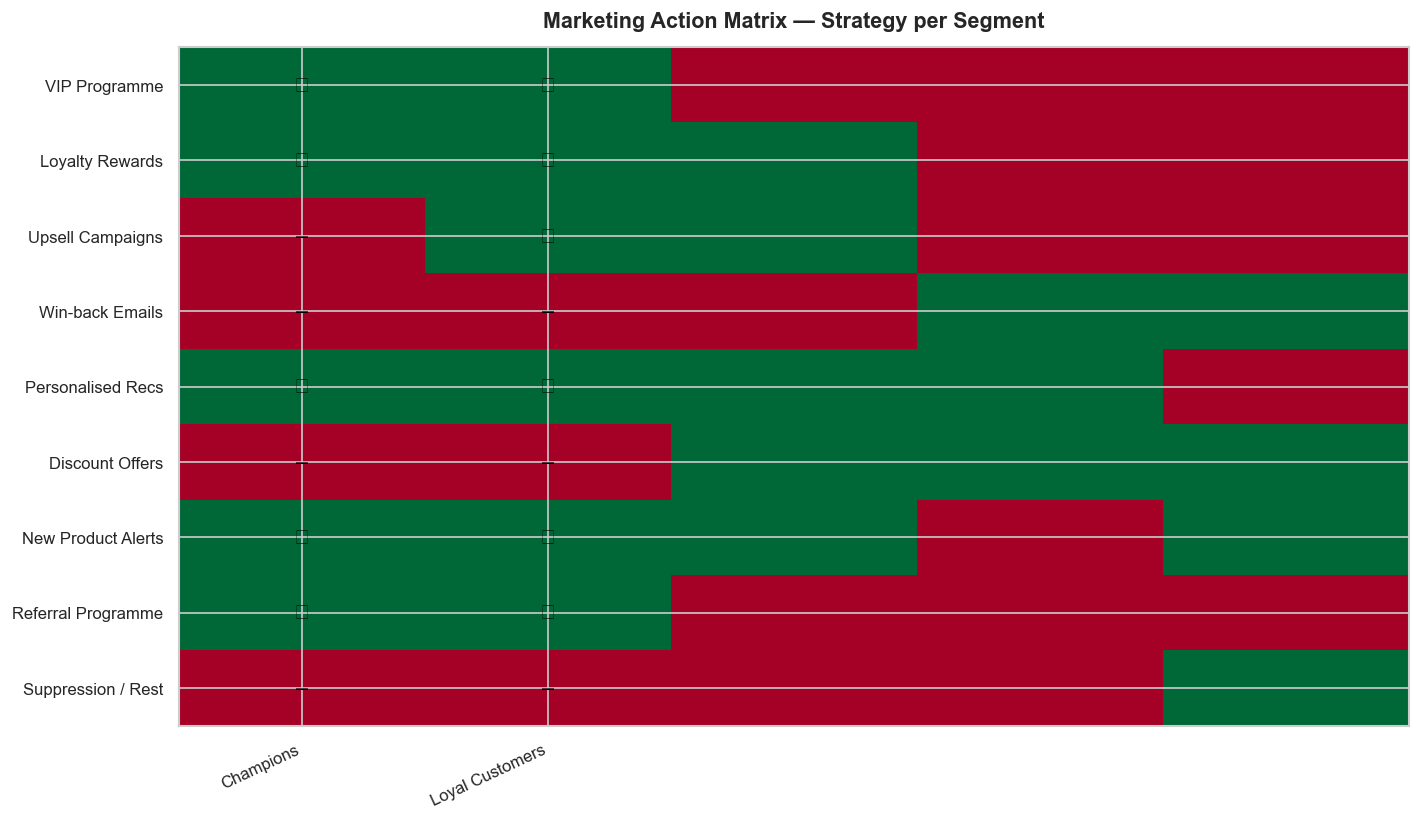

✅ Saved: marketing_action_matrix.png


In [15]:
# Marketing action matrix — visual strategy grid

actions = [
    'VIP Programme',
    'Loyalty Rewards',
    'Upsell Campaigns',
    'Win-back Emails',
    'Personalised Recs',
    'Discount Offers',
    'New Product Alerts',
    'Referral Programme',
    'Suppression / Rest',
]

segments = list(cluster_name_map.values())

# 1 = apply, 0 = skip  (rows=actions, cols=segments)
matrix = np.array([
# Champions  Loyal  PotLoyal  AtRisk  Lost
    [1,        1,     0,        0,      0],   # VIP
    [1,        1,     1,        0,      0],   # Loyalty rewards
    [0,        1,     1,        0,      0],   # Upsell
    [0,        0,     0,        1,      1],   # Win-back
    [1,        1,     1,        1,      0],   # Personalised recs
    [0,        0,     1,        1,      1],   # Discount offers
    [1,        1,     1,        0,      1],   # New product alerts
    [1,        1,     0,        0,      0],   # Referral
    [0,        0,     0,        0,      1],   # Suppression
], dtype=float)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(segments)))
ax.set_yticks(range(len(actions)))
ax.set_xticklabels(segments, rotation=25, ha='right', fontsize=10)
ax.set_yticklabels(actions, fontsize=10)

for i in range(len(actions)):
    for j in range(len(segments)):
        txt = '✓' if matrix[i, j] == 1 else '–'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=13, color='black')

ax.set_title('Marketing Action Matrix — Strategy per Segment',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('../results/cluster_plots/marketing_action_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: marketing_action_matrix.png")

In [16]:
# Save final enriched customer dataset

df.to_csv('../data/processed/final_segments.csv', index=False)

print("✅ Saved: data/processed/final_segments.csv")
print(f"\nFinal dataset columns: {df.columns.tolist()}")
print(f"Total customers     : {len(df):,}")
print(f"\nSegment summary:")
summary = df.groupby('Segment_Name').agg(
    Customers          = ('Customer ID',   'count'),
    Avg_Recency        = ('Recency',       'mean'),
    Avg_Frequency      = ('Frequency',     'mean'),
    Avg_Spend          = ('Monetary',      'mean'),
    Revenue_Share_Pct  = ('Monetary',      lambda x: x.sum()/df['Monetary'].sum()*100)
).round(2)
print(summary.to_string())

✅ Saved: data/processed/final_segments.csv

Final dataset columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems', 'AvgItemsPerOrder', 'UniqueProducts', 'NumCountries', 'CustomerAge', 'AvgDaysBetweenOrders', 'SpendPerItem', 'cancellation_rate', 'Final_Cluster', 'Segment_Name']
Total customers     : 5,878

Segment summary:
                 Customers  Avg_Recency  Avg_Frequency  Avg_Spend  Revenue_Share_Pct
Segment_Name                                                                        
Champions             5751       199.02           5.84    2353.72              97.87
Loyal Customers        127       302.50           3.15    2316.41               2.13


In [17]:
# Full project completion summary

print("""
╔══════════════════════════════════════════════════════════════╗
║          PROJECT COMPLETE — FULL PIPELINE SUMMARY           ║
╚══════════════════════════════════════════════════════════════╝

  DATASET
  ─────────────────────────────────────────────────
  Source     : UCI Online Retail II
  Records    : 525,000+ transactions
  Customers  : see above
  Features   : 11 engineered (RFM + behavioral)

  PREPROCESSING
  ─────────────────────────────────────────────────
  Missing    : CustomerID rows dropped
  Outliers   : Winsorized at 99th percentile
  Transform  : log1p on skewed features
  Scaler     : RobustScaler

  ALGORITHMS COMPARED
  ─────────────────────────────────────────────────
  ✅  K-Means          (k-means++ init)
  ✅  Hierarchical     (Ward linkage)
  ✅  DBSCAN           (k-distance eps tuning)
  ✅  GMM              (BIC component selection)

  EVALUATION METHODS
  ─────────────────────────────────────────────────
  ✅  Elbow Method
  ✅  Silhouette Score
  ✅  Davies-Bouldin Index
  ✅  BIC / AIC (GMM)
  ✅  Weighted final scoring

  DIMENSIONALITY REDUCTION
  ─────────────────────────────────────────────────
  ✅  PCA  (2D, 3D, 95% variance)
  ✅  t-SNE (bonus)

  BUSINESS DELIVERABLES
  ─────────────────────────────────────────────────
  ✅  Segment profiles with names
  ✅  Revenue contribution per segment
  ✅  Churn risk identification
  ✅  Marketing strategy per segment
  ✅  Personalised offer recommendations
  ✅  Marketing action matrix

  OUTPUTS
  ─────────────────────────────────────────────────
  📁  data/processed/final_segments.csv
  📁  results/cluster_plots/  (15+ plots)
  📁  results/pca_outputs/    (PCA + t-SNE)
  📁  results/metrics/        (scores CSV)
""")


╔══════════════════════════════════════════════════════════════╗
║          PROJECT COMPLETE — FULL PIPELINE SUMMARY           ║
╚══════════════════════════════════════════════════════════════╝

  DATASET
  ─────────────────────────────────────────────────
  Source     : UCI Online Retail II
  Records    : 525,000+ transactions
  Customers  : see above
  Features   : 11 engineered (RFM + behavioral)

  PREPROCESSING
  ─────────────────────────────────────────────────
  Missing    : CustomerID rows dropped
  Outliers   : Winsorized at 99th percentile
  Transform  : log1p on skewed features
  Scaler     : RobustScaler

  ALGORITHMS COMPARED
  ─────────────────────────────────────────────────
  ✅  K-Means          (k-means++ init)
  ✅  Hierarchical     (Ward linkage)
  ✅  DBSCAN           (k-distance eps tuning)
  ✅  GMM              (BIC component selection)

  EVALUATION METHODS
  ─────────────────────────────────────────────────
  ✅  Elbow Method
  ✅  Silhouette Score
  ✅  Davies-Boul